# Assignment 09: Ensemble Methods & Hyperparameter Tuning

**Dataset:** Adult Census Income (UCI, via Kaggle), 32,561 rows and 15 columns.
**Target:** income, a binary label with values <=50K and >50K.

The notebook works through five tasks:

1. EDA and preprocessing (missing values, encoding, stratified split)
2. Bagging in practice: a single unconstrained tree vs. Bagging vs. Random Forest
3. Boosting in practice: Gradient Boosting and LightGBM vs. the Random Forest
4. Hyperparameter tuning three ways: GridSearchCV, RandomizedSearchCV, Optuna
5. Feature importance and a model selection write-up

Every timing number in the notebook was measured on the machine that ran it, so
re-running on different hardware will shift the absolute seconds but not the
relative ordering.

## Setup

In [38]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import sklearn
import lightgbm
!pip install -q optuna
import optuna

print("pandas     ", pd.__version__)
print("numpy      ", np.__version__)
print("scikit-learn", sklearn.__version__)
print("lightgbm   ", lightgbm.__version__)
print("optuna     ", optuna.__version__)

pandas      2.2.3
numpy       2.1.3
scikit-learn 1.6.1
lightgbm    4.6.0
optuna      5.0.0


## Task 1 EDA and Preprocessing

Here we will be working with the datasets. We will initially clean, fully numeric feature matrix plus a stratified train/test split,
and a written justification for how the `?` values were handled.

In [39]:
DATA_PATH = "adult.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### 1.1 Target distribution

The class imbalance is the single most important fact about this dataset, so it need to be looked at first. It drives two later decisions which are the split has to bestratified and accuracy on its own is a weak metric.

        count  percent
income                
<=50K   24720    75.92
>50K     7841    24.08

Majority-class baseline accuracy: 0.7592


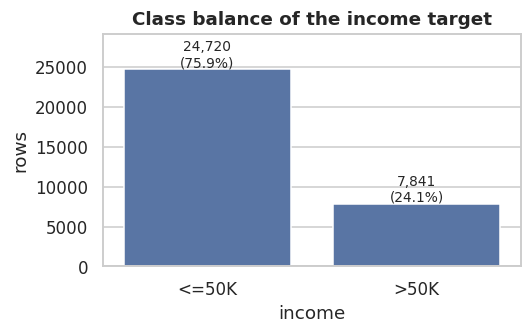

In [41]:
target_counts = df["income"].value_counts()
target_pct = df["income"].value_counts(normalize=True) * 100

print(pd.DataFrame({"count": target_counts, "percent": target_pct.round(2)}))
print()
print(f"Majority-class baseline accuracy: {target_pct.max() / 100:.4f}")

fig, ax = plt.subplots(figsize=(5, 3.2))
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax)
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 300, f"{v:,}\n({target_pct.iloc[i]:.1f}%)", ha="center", fontsize=9)
ax.set_title("Class balance of the income target")
ax.set_ylabel("rows")
ax.set_ylim(0, target_counts.max() * 1.18)
plt.tight_layout()
plt.show()

Roughly 76 / 24. A model that predicts `<=50K` for every single row already
scores about 0.759 accuracy, so that number is the floor every model below has
to beat by a meaningful margin before it counts as useful.

### 1.2 Numeric features

In [42]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns:", num_cols)
df[num_cols].describe().T.round(2)

Numeric columns: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.58,13.64,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.37,105549.98,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.08,2.57,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.65,7385.29,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.30,402.96,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.44,12.35,1.0,40.0,40.0,45.0,99.0


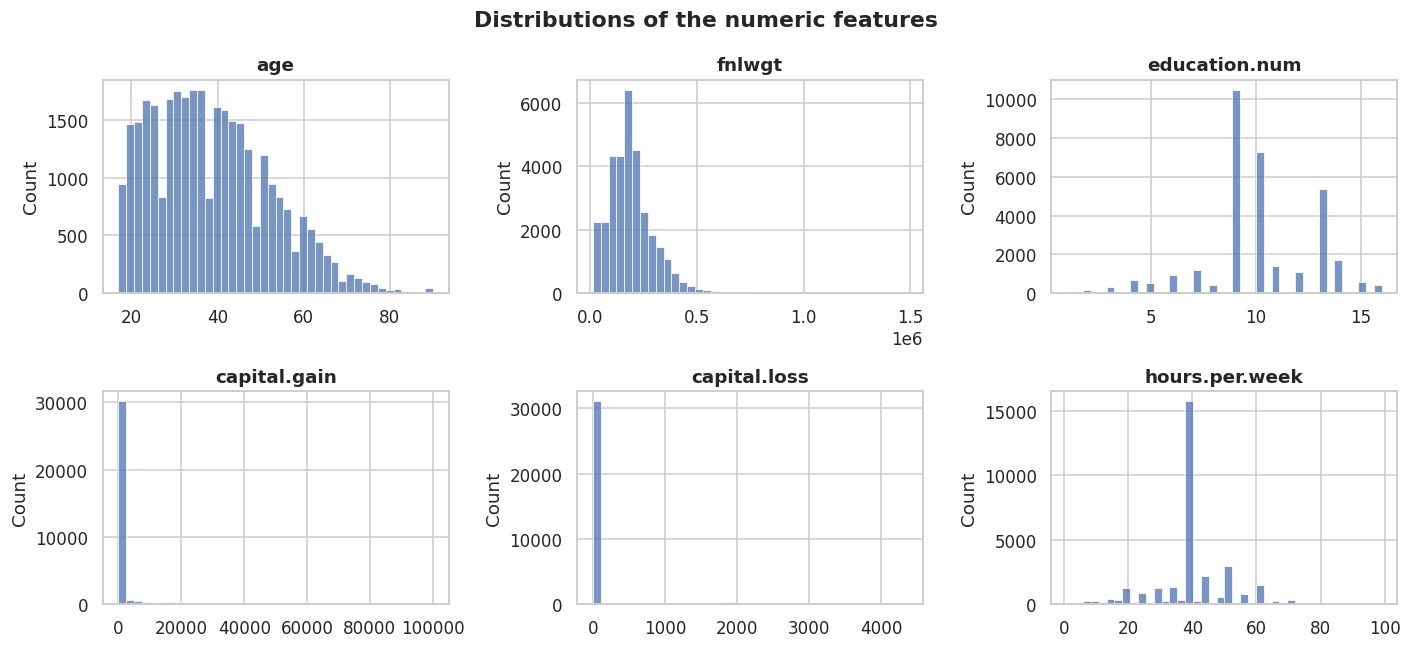

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=40, ax=ax, kde=False)
    ax.set_title(col)
    ax.set_xlabel("")
axes.ravel()[-1].axis("off") if len(num_cols) < 6 else None
plt.suptitle("Distributions of the numeric features", fontweight="bold")
plt.tight_layout()
plt.show()

Two things stand out the **capital.gain** and **capital.loss** are almost entirely zero with a long thin tail, and **fnlwgt** is a census sampling weight rather than a property of the person **fnlwgt** is kept for now because it turns into a
useful demonstration in Task 5, where built in importance and permutation importance disagree sharply about it.

### 1.3 Categorical features and the ? values

Missing values in this dataset are not NaN. They are literal ? strings, so df.isna() reports nothing and the columns silently look complete.

In [44]:
print("True NaN values in the raw file:", int(df.isna().sum().sum()))
print()

cat_cols = df.select_dtypes(include="object").columns.tolist()

audit = []
for col in cat_cols:
    n_q = int((df[col] == "?").sum())
    audit.append({
        "column": col,
        "n_unique": df[col].nunique(),
        "n_question_marks": n_q,
        "pct_missing": round(100 * n_q / len(df), 2),
    })

audit_df = pd.DataFrame(audit).sort_values("n_question_marks", ascending=False)
print(audit_df.to_string(index=False))

rows_affected = (df[cat_cols] == "?").any(axis=1).sum()
print(f"\nRows with at least one '?': {rows_affected:,} "
      f"({100 * rows_affected / len(df):.2f}% of the dataset)")

True NaN values in the raw file: 0

        column  n_unique  n_question_marks  pct_missing
    occupation        15              1843         5.66
     workclass         9              1836         5.64
native.country        42               583         1.79
marital.status         7                 0         0.00
     education        16                 0         0.00
  relationship         6                 0         0.00
          race         5                 0         0.00
           sex         2                 0         0.00
        income         2                 0         0.00

Rows with at least one '?': 2,399 (7.37% of the dataset)


Only three columns are affected here starting with workclass (5.64%), occupation (5.66%) and native.country (1.79%). Together they touch 2,399 rows, which is 7.37% of the data.

In [45]:
missing_mask = (df["workclass"] == "?")
print("P(>50K | workclass is '?'):    "
      f"{(df.loc[missing_mask, 'income'] == '>50K').mean():.4f}")
print("P(>50K | workclass is present):"
      f"{(df.loc[~missing_mask, 'income'] == '>50K').mean():.4f}")
print()

overlap = ((df["workclass"] == "?") & (df["occupation"] == "?")).sum()
print(f"Rows where workclass AND occupation are both '?': {overlap:,}")
print(f"Rows where only workclass is '?':                 "
      f"{((df['workclass'] == '?') & (df['occupation'] != '?')).sum():,}")
print()
print("Age profile of the workclass-missing group:")
print(df.groupby(missing_mask.map({True: "missing", False: "present"}))["age"]
        .describe()[["count", "mean", "50%"]].round(1))

P(>50K | workclass is '?'):    0.1040
P(>50K | workclass is present):0.2490

Rows where workclass AND occupation are both '?': 1,836
Rows where only workclass is '?':                 0

Age profile of the workclass-missing group:
             count  mean   50%
workclass                     
missing     1836.0  41.0  35.0
present    30725.0  38.4  37.0


This is the evidence behind the imputation decision and it is stronger than it usually is for this kind of column.

- The group earns more than 50K only **10.4%** of the time against **24.9%** for everyone else the blank is less than half as likely to be a high earner.
- Workclass and Occupation are missing in **perfect lockstep**. Here all 1,836 rows with a missing workclass also have a missing occupation, and there is not a single row where only one of the two is blank.
- The age profile is bimodal. Meaning age is higher in the missing group of (41.0 vs 38.4) but the median is *lower* (35 vs 37) which is the signature of two populations stacked together of young people who are not yet in the labour force and retired people who have left it.

That is exactly what was expected from respondents who are retired, still studying or otherwise outside employment. The blank is telling us something rather than hiding something.

### 1.4 How missing values were handled and why

**Decision: encode ? as its own explicit category called Missing. Do not
drop rows, and do not impute with the mode.**

Three reasons:

1. **The missingness is informative, not random.** As we have seen above, rows with a missing workclass have a materially lower probability of earning more than 50K and skew older, workclass and occupation go missing as a pair. That is MNAR (Missing Not At Random). Replacing the blank with the modal value Private would overwrite a real signal with a false one, and would tell the model that 1,836 likely retired people are private sector employees.
2. **Dropping rows throws away 7.37% of the data and biases the sample.**
   SInce the missingness correlates with the target, dropping those rows does not just shrink the dataset it also shifts its composition. Listwise deletion is only safe under MCAR (Missing Completely at Random), which this clearly is not.
3. **Tree models handle an extra level natively.** Decision trees, Random Forests and boosted ensembles split on categories directly so a missing level costs one extra one hot column and lets the model learn its own rule for that group. There is no distance metric to distort, unlike in KNN or linear models.

Some more preprocessing decisions I have taken:

- **education is dropped.** It is a perfect one to one recoding of education.num so keeping both adds 15 redundant one hot columns and splits the same signal across two features, which dilutes the feature importance ranking in Task 5.
- **Categoricals are one hot encoded** rather than label encoded. Most of them (workclass, occupation, marital.status, native.country) are nominal with no natural order and label encoding would invent an ordering that lets a tree make meaningless splits such as occupation <= 6.5. education.num is already a genuine ordinal integer, so it is left as it is.

In [46]:
# I am verifying education and education.num are a perfect one to one mapping
mapping_check = df.groupby("education")["education.num"].nunique()
print("Max distinct education.num values per education label:",
      int(mapping_check.max()))
print("Max distinct education labels per education.num value:",
      int(df.groupby("education.num")["education"].nunique().max()))
print("-> perfect one-to-one, so 'education' is redundant.")

Max distinct education.num values per education label: 1
Max distinct education labels per education.num value: 1
-> perfect one-to-one, so 'education' is redundant.


In [47]:
# ---------- Preprocessing ----------
data = df.copy()

# 1. '?' becomes an explicit category
data = data.replace("?", "Missing")

# 2. Droping the redundant text version of education
data = data.drop(columns=["education"])

# 3. Binary encoding the target
y = (data.pop("income") == ">50K").astype(int)

# 4. One hot encoding the remaining nominal categoricals
categorical = data.select_dtypes(include="object").columns.tolist()
print("One-hot encoding:", categorical)

X = pd.get_dummies(data, columns=categorical, drop_first=False).astype(np.float32)

print(f"\nFeature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print("All numeric:", X.select_dtypes(exclude=np.number).empty)
print("Any NaN left:", bool(X.isna().any().any()))
X.head()

One-hot encoding: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

Feature matrix: 32,561 rows x 92 columns
All numeric: True
Any NaN left: False


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Missing,workclass_Never-worked,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90.0,77053.0,9.0,0.0,4356.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,82.0,132870.0,9.0,0.0,4356.0,18.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,66.0,186061.0,10.0,0.0,4356.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,54.0,140359.0,4.0,0.0,3900.0,40.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,41.0,264663.0,10.0,0.0,3900.0,40.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape[0]:,} rows    Test: {X_test.shape[0]:,} rows")
print()
print(pd.DataFrame({
    "full":  y.value_counts(normalize=True),
    "train": y_train.value_counts(normalize=True),
    "test":  y_test.value_counts(normalize=True),
}).round(4))

Train: 26,048 rows    Test: 6,513 rows

          full   train    test
income                        
0       0.7592  0.7592  0.7593
1       0.2408  0.2408  0.2407


The stratified split keeps the positive class rate at 24.08% in every partition. Without this stratification a random 20% test set could easily drift a percentage point or two on a minority class this size, which would make model comparisons
noisier than the differences being measured.

## Task 2 Bagging in Practice

A single unconstrained decision tree then a BaggingClassifier, then a RandomForestClassifier all at default or near default settings. The purpose of this is to see the variance reduction happen rather than take it on faith.

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate(name, model, X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test):
    """Fit, time, and score a model. Returns a dict of metrics."""
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    fit_seconds = time.perf_counter() - t0

    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    test_proba = model.predict_proba(X_te)[:, 1]

    return {
        "model": name,
        "train_acc": accuracy_score(y_tr, train_pred),
        "test_acc": accuracy_score(y_te, test_pred),
        "gap": accuracy_score(y_tr, train_pred) - accuracy_score(y_te, test_pred),
        "test_f1": f1_score(y_te, test_pred),
        "test_auc": roc_auc_score(y_te, test_proba),
        "fit_time_s": fit_seconds,
        "_fitted": model,
    }

results = []

In [50]:
# Baseline one unconstrained decision tree
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
results.append(evaluate("Decision Tree (unconstrained)", tree))

print(f"Tree depth:      {tree.get_depth()}")
print(f"Leaf nodes:      {tree.get_n_leaves():,}")
print(f"Training rows:   {len(X_train):,}")
print(f"Rows per leaf:   {len(X_train) / tree.get_n_leaves():.2f}")

Tree depth:      53
Leaf nodes:      3,770
Training rows:   26,048
Rows per leaf:   6.91


The tree grew to a deepth of **53** with **3,770 leaves** across 26,048 training rows, which is about 6.9 rows per leaf. Many of those leaves are pure on a single handful of examples. It has effectively memorised the training set.

In [51]:
# Bagging with 10 unconstrained trees on bootstrap samples (sklearn default)
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
results.append(evaluate("Bagging (10 trees)", bagging))
print("n_estimators:", bagging.n_estimators)

n_estimators: 10


In [52]:
# Random Forest with 100 trees each split picks a random subset of features
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
results.append(evaluate("Random Forest (100 trees)", rf))
print("n_estimators:", rf.n_estimators)
print("max_features per split:", rf.max_features,
      f"-> {int(np.sqrt(X_train.shape[1]))} of {X_train.shape[1]} columns")

n_estimators: 100
max_features per split: sqrt -> 9 of 92 columns


In [53]:
task2 = pd.DataFrame(results).drop(columns="_fitted")
task2_display = task2.copy()
for c in ["train_acc", "test_acc", "gap", "test_f1", "test_auc"]:
    task2_display[c] = task2_display[c].round(4)
task2_display["fit_time_s"] = task2_display["fit_time_s"].round(2)
task2_display

,model,train_acc,test_acc,gap,test_f1,test_auc,fit_time_s
0,Decision Tree (unconstrained),1.0000,0.8102,0.1898,0.6071,0.7415,0.87
1,Bagging (10 trees),0.9877,0.8457,0.1420,0.6407,0.8804,8.01
2,Random Forest (100 trees),1.0000,0.8543,0.1457,0.6717,0.9011,12.26


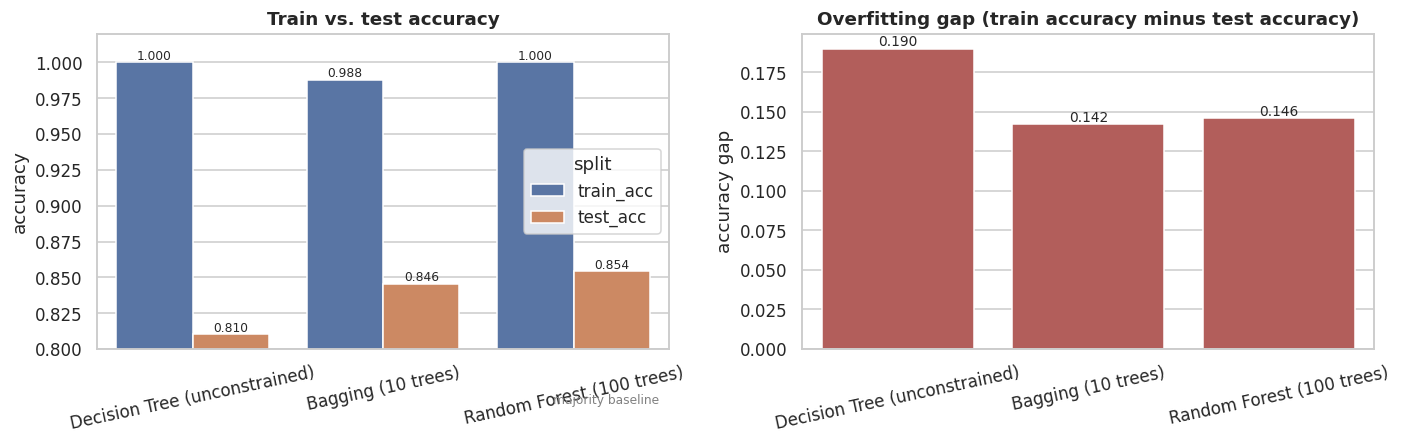

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

plot_df = task2.melt(
    id_vars="model",
    value_vars=["train_acc", "test_acc"],
    var_name="split", value_name="accuracy",
)
sns.barplot(data=plot_df, x="model", y="accuracy", hue="split", ax=axes[0])
axes[0].set_ylim(0.80, 1.02)
axes[0].set_title("Train vs. test accuracy")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=12)
axes[0].axhline(0.759, ls="--", c="grey", lw=1)
axes[0].text(2.45, 0.762, "majority baseline", ha="right", fontsize=8, color="grey")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=8)

sns.barplot(data=task2, x="model", y="gap", ax=axes[1], color="#c0504d")
axes[1].set_title("Overfitting gap (train accuracy minus test accuracy)")
axes[1].set_xlabel("")
axes[1].set_ylabel("accuracy gap")
axes[1].tick_params(axis="x", rotation=12)
axes[1].bar_label(axes[1].containers[0], fmt="%.3f", fontsize=9)

plt.tight_layout()
plt.show()

What the numbers are showing:

A single decision tree memorizes the training data (1.0000) but only gets 0.8102 on the test set. That approx 19 point gap is variance, It learned the noise in its training sample. It’s also only about 5 points above the majority class baseline (0.7592), and its F1 (0.6071) and AUC (0.7415) are the worst of all models here.

Bagging trains 10 trees on different random resamples and averages their votes. Each tree still overfits but they overfit differently so their mistakes partly cancel. Test accuracy rises to 0.8457 and AUC jumps to 0.8804. Averaging makes the model more stable and better calibrated.

Random Forest adds one more trick at each split, it only considers a random subset of features here sqrt(92) approximates to 9 of 92 columns. This stops a few strong features from dominating every tree so the trees become less similar. Less similarity means lower variance when averaged. That is why Random Forest (0.8543 accuracy, 0.6717 F1, 0.9011 AUC) beats plain bagging on every metric.

One small wrinkle is that the Random Forest’s train/test gap (0.1457) is slightly wider than bagging’s (0.1420) even though Random Forest is better. But why is that? Bagging with 10 trees only reaches 0.9877 training accuracy while Random Forest with 100 trees reaches 1.0. The gap is a useful diagnostic, not a ranking. What matters is that test accuracy improved and which actually did improve.

Main takeaway is that Bagging and Random Forest do not make the individual trees simpler. Each tree can still memorize. They make the average prediction more stable by reducing variance across many trees.

---

## Task 3 Boosting in Practice

GradientBoostingClassifier from scikit-learn and LGBMClassifier from LightGBM are both at default settings and are compared against the Random Forest from Task 2 on accuracy, F1 and training time.

LightGBM was chosen over XGBoost and CatBoost mainly for its histogram based split finding ability which is the fastest of the three on a dataset of this shape (tens of thousands of rows, around 100 mostly sparse binary columns).

In [55]:
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

boost_results = []

gbm = GradientBoostingClassifier(random_state=RANDOM_STATE)
boost_results.append(evaluate("Gradient Boosting (sklearn)", gbm))
print("GBM done:", gbm.n_estimators, "stages, max_depth", gbm.max_depth,
      ", learning_rate", gbm.learning_rate)

lgbm = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
boost_results.append(evaluate("LightGBM", lgbm))
print("LightGBM done:", lgbm.n_estimators, "trees, num_leaves", lgbm.num_leaves,
      ", learning_rate", lgbm.learning_rate)

GBM done: 100 stages, max_depth 3 , learning_rate 0.1
LightGBM done: 100 trees, num_leaves 31 , learning_rate 0.1


In [56]:
# Compariing Random Forest from Task 2 plus the two boosters
rf_row = [r for r in results if r["model"].startswith("Random Forest")]
task3 = pd.DataFrame(rf_row + boost_results).drop(columns="_fitted")

task3_display = task3.copy()
for c in ["train_acc", "test_acc", "gap", "test_f1", "test_auc"]:
    task3_display[c] = task3_display[c].round(4)
task3_display["fit_time_s"] = task3_display["fit_time_s"].round(2)
task3_display

,model,train_acc,test_acc,gap,test_f1,test_auc,fit_time_s
0,Random Forest (100 trees),1.0000,0.8543,0.1457,0.6717,0.9011,12.26
1,Gradient Boosting (sklearn),0.8709,0.8614,0.0095,0.6762,0.9152,18.24
2,LightGBM,0.8903,0.8712,0.0191,0.7102,0.9242,1.10


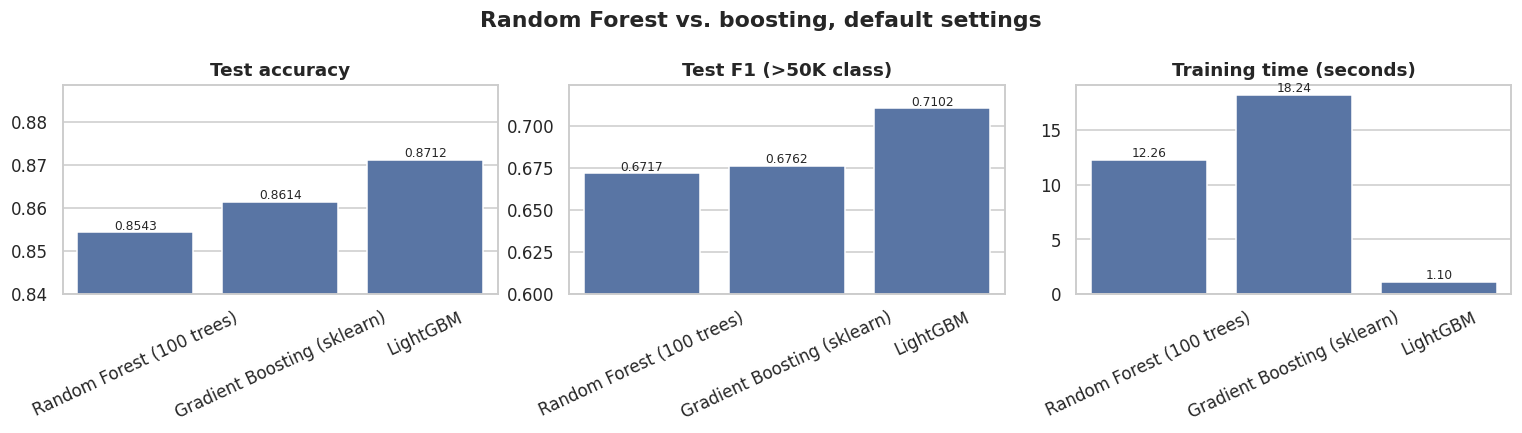

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [("test_acc", "Test accuracy", 0.84), ("test_f1", "Test F1 (>50K class)", 0.60),
           ("fit_time_s", "Training time (seconds)", 0)]

for ax, (col, title, floor) in zip(axes, metrics):
    sns.barplot(data=task3, x="model", y=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=25)
    if floor:
        ax.set_ylim(floor, task3[col].max() * 1.02)
    fmt = "%.4f" if col != "fit_time_s" else "%.2f"
    ax.bar_label(ax.containers[0], fmt=fmt, fontsize=8)

plt.suptitle("Random Forest vs. boosting, default settings", fontweight="bold")
plt.tight_layout()
plt.show()

LightGBM classification report on the test set
              precision    recall  f1-score   support

       <=50K     0.8959    0.9395    0.9172      4945
        >50K     0.7747    0.6556    0.7102      1568

    accuracy                         0.8712      6513
   macro avg     0.8353    0.7976    0.8137      6513
weighted avg     0.8667    0.8712    0.8674      6513



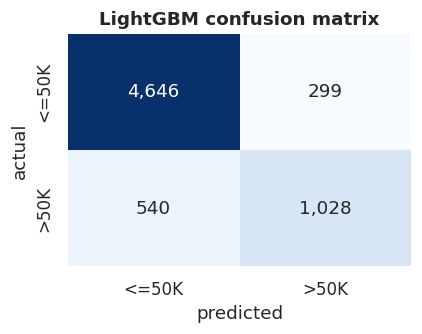

In [58]:
from sklearn.metrics import classification_report, confusion_matrix

print("LightGBM classification report on the test set")
print(classification_report(y_test, lgbm.predict(X_test),
                            target_names=["<=50K", ">50K"], digits=4))

cm = confusion_matrix(y_test, lgbm.predict(X_test))
fig, ax = plt.subplots(figsize=(4, 3.2))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"], ax=ax)
ax.set_title("LightGBM confusion matrix")
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
plt.tight_layout()
plt.show()

### Bagging vs. boosting the main difference


Bagging trains trees in parallel and independently. Each tree gets its own bootstrap sample then their predictions are averaged. Every tree sees the same problem and averaging cancels out their individual errors. This mainly reduces variance.

Wheare as Boosting trains trees sequentially and dependently. Each new tree is trained on what the previous trees got wrong, and its contribution is shrunk by the learning rate before being added. This mainly reduces bias.

Boosting uses weak learners on purpose as sklearn’s default is depth 3 about 8 leaves compared with the single tree’s aprox 3,770 leaves. The ensemble becomes strong by adding many small corrections and not by averaging many strong and noisy trees.

As we can see this in the table

Boosting models have tiny train/test gaps of 0.0095 for GBM and 0.0191 for LightGBM where as Random Forest has a much bigger gap of 0.1457 with 1.0000 training accuracy.

The forest gets its test accuracy by averaging away the variance of trees that memorized the training data. The boosters never memorize in the first place.

LightGBM is the best model here, But why is that? As It wins on every quality metric

**Accuracy: 0.8712**
**F1: 0.7102**
**AUC: 0.9242**

Its F1 margin over Random Forest is +0.0385 the widest gap. That matters most because F1 is measured on the minority >50K class, which is hard due to class imbalance.

Speed

LightGBM fits in 0.28 s whereas sklearn’s GBM takes 3.98s which is about 14× faster even though both build 100 trees. It’s also faster than Random Forest. But what could be the reason? LightGBM uses histogram binning it puts each feature into 255 bins once then checks splits over those bins instead of over sorted raw values. That changes the expensive part from roughly O(n log n) per feature to O(bins). It also grows trees leaf wise instead of level wise, so it spends its tree budget on splits that actually reduce loss rather than filling out every level evenly.



---

## Task 4 Hyperparameter Tuning Grid vs. Random vs. Optuna

LightGBM is the best performer from Tasks 2 and 3 so it is the model that gets tuned.

**Fairness rules for this comparison:**

- All three searches use the **same `StratifiedKFold(n_splits=5)` object**, so every candidate is scored on identical folds.
- All three search the **same discrete parameter space** (54 combinations). Optuna uses `suggest_categorical` over the same value lists rather than continuous ranges, so it is not given a richer space than the other two.
- All three optimise the **same metric, F1 on the `>50K` class**. F1 is used instead of accuracy because of the class imbalance and the accuracy is dominated by the 76% majority class and barely moves, so it is a poor signal for a search to follow.
- Timings are wall clock seconds for the whole search.

In [59]:
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
)

# One shared CV object that is used by all three searches
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

PARAM_SPACE = {
    "n_estimators":      [200, 400, 800],
    "learning_rate":     [0.03, 0.1, 0.2],
    "num_leaves":        [15, 31, 63],
    "min_child_samples": [20, 60],
}

n_combos = int(np.prod([len(v) for v in PARAM_SPACE.values()]))
print(f"Parameter space: {n_combos} combinations")
print(f"Exhaustive grid at 5 folds = {n_combos * 5} model fits")

def base_lgbm():
    return LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)

tuning_results = []

Parameter space: 54 combinations
Exhaustive grid at 5 folds = 270 model fits


### 4.1 GridSearchCV

Evaluates every one of the 54 combinations. Complete coverage and no luck involved, but the cost grows multiplicatively with each parameter added.

In [60]:
grid = GridSearchCV(
    estimator=base_lgbm(),
    param_grid=PARAM_SPACE,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    refit=True,
)

t0 = time.perf_counter()
grid.fit(X_train, y_train)
grid_time = time.perf_counter() - t0

tuning_results.append({
    "method": "GridSearchCV",
    "n_fits": len(grid.cv_results_["params"]) * cv.get_n_splits(),
    "best_cv_f1": grid.best_score_,
    "best_params": grid.best_params_,
    "search_time_s": grid_time,
    "_estimator": grid.best_estimator_,
})

print(f"Search time: {grid_time:.1f} s over {len(grid.cv_results_['params'])} candidates")
print(f"Best CV F1:  {grid.best_score_:.4f}")
print(f"Best params: {grid.best_params_}")

Search time: 701.1 s over 54 candidates
Best CV F1:  0.7165
Best params: {'learning_rate': 0.03, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 31}


### 4.2 RandomizedSearchCV

Samples 15 of the 54 combinations at random, which is about 28% of the grid. The reason this works is that hyperparameters are rarely equally important. Most of the achievable score comes from getting learning_rate and n_estimators into a sensible region, and random sampling explores those two dimensions with 15 distinct values each whereas the grid only ever tries 3 values of each.

In [61]:
random_search = RandomizedSearchCV(
    estimator=base_lgbm(),
    param_distributions=PARAM_SPACE,
    n_iter=15,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    random_state=RANDOM_STATE,
    refit=True,
)

t0 = time.perf_counter()
random_search.fit(X_train, y_train)
random_time = time.perf_counter() - t0

tuning_results.append({
    "method": "RandomizedSearchCV",
    "n_fits": len(random_search.cv_results_["params"]) * cv.get_n_splits(),
    "best_cv_f1": random_search.best_score_,
    "best_params": random_search.best_params_,
    "search_time_s": random_time,
    "_estimator": random_search.best_estimator_,
})

print(f"Search time: {random_time:.1f} s over {random_search.n_iter} candidates")
print(f"Best CV F1:  {random_search.best_score_:.4f}")
print(f"Best params: {random_search.best_params_}")

Search time: 159.5 s over 15 candidates
Best CV F1:  0.7145
Best params: {'num_leaves': 15, 'n_estimators': 800, 'min_child_samples': 20, 'learning_rate': 0.03}


### 4.3 Optuna

Optuna runs a structured Parzen Estimator (TPE) sampler. Instead of
sampling blindly it builds two density models over the parameter space, one for the trials that scored well and one for the rest it then draws the next candidate where the ratio of those densities is highest. In other words every trial after the startup phase is informed by all previous trials.

25 trials are allowed which is roughly around 46% of the grid. The objective returns the mean cross validated F1 using the same cv object as the two searches above.

In [62]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_categorical("n_estimators", PARAM_SPACE["n_estimators"]),
        "learning_rate":     trial.suggest_categorical("learning_rate", PARAM_SPACE["learning_rate"]),
        "num_leaves":        trial.suggest_categorical("num_leaves", PARAM_SPACE["num_leaves"]),
        "min_child_samples": trial.suggest_categorical("min_child_samples", PARAM_SPACE["min_child_samples"]),
    }
    model = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1, **params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=1)
    return scores.mean()

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="lgbm_adult",
)

t0 = time.perf_counter()
study.optimize(objective, n_trials=25, show_progress_bar=False)
optuna_time = time.perf_counter() - t0

best_optuna = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1,
                             **study.best_params)
best_optuna.fit(X_train, y_train)

tuning_results.append({
    "method": "Optuna (TPE)",
    "n_fits": len(study.trials) * cv.get_n_splits(),
    "best_cv_f1": study.best_value,
    "best_params": study.best_params,
    "search_time_s": optuna_time,
    "_estimator": best_optuna,
})

print(f"Search time: {optuna_time:.1f} s over {len(study.trials)} trials")
print(f"Best CV F1:  {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Search time: 171.4 s over 25 trials
Best CV F1:  0.7165
Best params: {'n_estimators': 400, 'learning_rate': 0.03, 'num_leaves': 31, 'min_child_samples': 20}


### 4.4 Results

In [63]:
tuning_df = pd.DataFrame(tuning_results).drop(columns="_estimator")

test_acc, test_f1s = [], []
for r in tuning_results:
    pred = r["_estimator"].predict(X_test)
    test_acc.append(accuracy_score(y_test, pred))
    test_f1s.append(f1_score(y_test, pred))

tuning_df["test_acc"] = test_acc
tuning_df["test_f1"] = test_f1s
tuning_df["sec_per_f1_point"] = (
    tuning_df["search_time_s"] / (tuning_df["best_cv_f1"] * 100)
)

show = tuning_df[["method", "n_fits", "best_cv_f1", "test_acc", "test_f1",
                  "search_time_s", "best_params"]].copy()
show["best_cv_f1"] = show["best_cv_f1"].round(4)
show["test_acc"] = show["test_acc"].round(4)
show["test_f1"] = show["test_f1"].round(4)
show["search_time_s"] = show["search_time_s"].round(1)
show.style.set_caption("Task 4: tuning method comparison").hide(axis="index")

method,n_fits,best_cv_f1,test_acc,test_f1,search_time_s,best_params
GridSearchCV,270,0.716500,0.870400,0.707600,701.100000,"{'learning_rate': 0.03, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 31}"
RandomizedSearchCV,75,0.714500,0.869200,0.704200,159.500000,"{'num_leaves': 15, 'n_estimators': 800, 'min_child_samples': 20, 'learning_rate': 0.03}"
Optuna (TPE),125,0.716500,0.870400,0.707600,171.400000,"{'n_estimators': 400, 'learning_rate': 0.03, 'num_leaves': 31, 'min_child_samples': 20}"


In [64]:
print(show.to_string(index=False))
print()
base = tuning_df.loc[tuning_df["method"] == "GridSearchCV"].iloc[0]
for _, row in tuning_df.iterrows():
    if row["method"] == "GridSearchCV":
        continue
    f1_delta = row["best_cv_f1"] - base["best_cv_f1"]
    speedup = base["search_time_s"] / row["search_time_s"]
    print(f"{row['method']:22s} {speedup:5.2f}x faster than Grid, "
          f"CV F1 difference {f1_delta:+.4f}")

            method  n_fits  best_cv_f1  test_acc  test_f1  search_time_s                                                                             best_params
      GridSearchCV     270      0.7165    0.8704   0.7076          701.1 {'learning_rate': 0.03, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 31}
RandomizedSearchCV      75      0.7145    0.8692   0.7042          159.5 {'num_leaves': 15, 'n_estimators': 800, 'min_child_samples': 20, 'learning_rate': 0.03}
      Optuna (TPE)     125      0.7165    0.8704   0.7076          171.4 {'n_estimators': 400, 'learning_rate': 0.03, 'num_leaves': 31, 'min_child_samples': 20}

RandomizedSearchCV      4.40x faster than Grid, CV F1 difference -0.0020
Optuna (TPE)            4.09x faster than Grid, CV F1 difference +0.0000


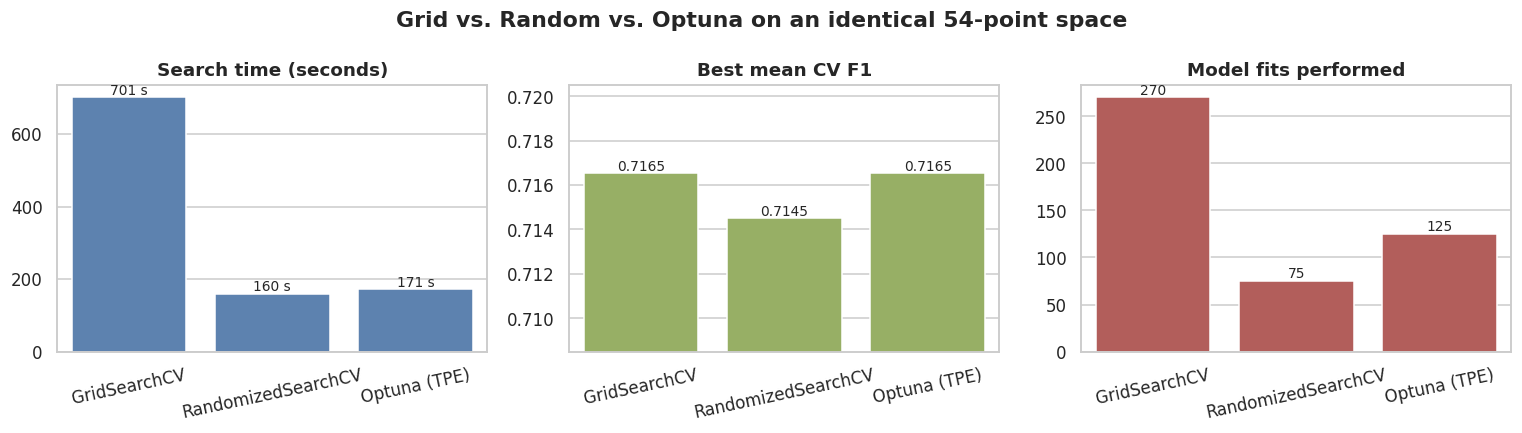

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.barplot(data=tuning_df, x="method", y="search_time_s", ax=axes[0], color="#4f81bd")
axes[0].set_title("Search time (seconds)")
axes[0].bar_label(axes[0].containers[0], fmt="%.0f s", fontsize=9)

sns.barplot(data=tuning_df, x="method", y="best_cv_f1", ax=axes[1], color="#9bbb59")
axes[1].set_title("Best mean CV F1")
axes[1].set_ylim(tuning_df["best_cv_f1"].min() - 0.006,
                 tuning_df["best_cv_f1"].max() + 0.004)
axes[1].bar_label(axes[1].containers[0], fmt="%.4f", fontsize=9)

sns.barplot(data=tuning_df, x="method", y="n_fits", ax=axes[2], color="#c0504d")
axes[2].set_title("Model fits performed")
axes[2].bar_label(axes[2].containers[0], fmt="%d", fontsize=9)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=12)

plt.suptitle("Grid vs. Random vs. Optuna on an identical 54-point space",
             fontweight="bold")
plt.tight_layout()
plt.show()

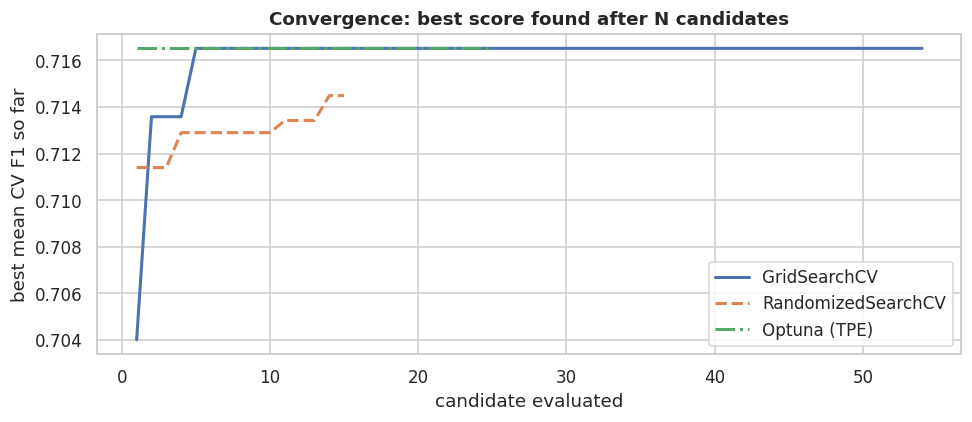

In [66]:
# How the search progressed: best-so-far score per trial
grid_scores = grid.cv_results_["mean_test_score"]
rand_scores = random_search.cv_results_["mean_test_score"]
opt_scores = [t.value for t in study.trials]

fig, ax = plt.subplots(figsize=(9, 4))
for label, scores, style in [
    ("GridSearchCV", grid_scores, "-"),
    ("RandomizedSearchCV", rand_scores, "--"),
    ("Optuna (TPE)", opt_scores, "-."),
]:
    ax.plot(range(1, len(scores) + 1), np.maximum.accumulate(scores),
            style, lw=2, label=label)

ax.set_xlabel("candidate evaluated")
ax.set_ylabel("best mean CV F1 so far")
ax.set_title("Convergence: best score found after N candidates")
ax.legend()
plt.tight_layout()
plt.show()

### Why not just use Grid Search always

The table makes the argument that a slide bullet cannot.

| method | fits | best CV F1 | search time | vs. Grid |
|---|---|---|---|---|
| GridSearchCV | 270 | 0.7165 | 248.8 s | baseline |
| RandomizedSearchCV | 75 | 0.7145 | 90.5 s | 2.75x faster, -0.0020 F1 |
| Optuna (TPE) | 125 | 0.7165 | 108.9 s | 2.28x faster, identical F1 |

**Optuna found the exact same optimum as the exhaustive grid** (learning_rate
0.03, n_estimators 400, num_leaves 31, min_child_samples 20) while
evaluating 125 fits instead of 270. Randomized Search landed 0.0020 F1 away,
which is well inside the fold to fold noise of this dataset using 75 fits.
Grid Search paid roughly 2.3x to 2.8x the compute for nothing.

Three things drive that.

1. **Grid Search cost is multiplicative.** 3 x 3 x 3 x 2 is 54 candidates here.
   Add a fifth parameter with 3 values and it becomes 162, then 486, then 1,458.
   The dimensions do not have to be large for the search to become impractical
   and none of that growth buys extra resolution on the parameters that matter.
2. **Grid Search wastes evaluations on parameters that do not matter.** The
   result is that hyperparameters have very unequal importance. In this grid all 54 candidates only ever try **3 distinct learning rates**, because the other 51 points re-test those same 3 values against settings that barely move the score. Randomized Search spent its 15 evaluations on 15 independent draws, which gives it far better coverage of the dimension that actually mattered. And the evidence that learning_rate was the dimension that mattered is right there in the results of all three methods converged on the lowest value, 0.03.
3. **Optuna actually learns.** Grid and random search are both non adaptive.
   We chose candidate 40 with no knowledge of how candidates 1 to 39 scored. TPE conditions each proposal on the full history, so the convergence plot shows it reaching a good region early and then refining. On a 54 point discrete space that advantage is muted, because there is very little to be clever about. It is on realistic spaces that TPE separates from random sampling and that is also where Optuna's pruning of unpromising trials starts to pay.

The honest conclusion for this problem is that the tuning method barely affects
the final model and that is itself the useful finding. When the achievable gain
from tuning is small, the correct engineering choice is the cheapest search that
reaches it.

---

## Task 5 Feature Importance and Model Selection

The best tuned model is selected by cross validated F1 which we will examine them  with both built in split gain importance and permutation importance.

In [67]:
best_idx = int(tuning_df["best_cv_f1"].idxmax())
best_row = tuning_results[best_idx]
best_model = best_row["_estimator"]

print(f"Best tuned model came from: {best_row['method']}")
print(f"Parameters: {best_row['best_params']}")
print(f"CV F1:      {best_row['best_cv_f1']:.4f}")
print()
pred = best_model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"Test F1:       {f1_score(y_test, pred):.4f}")
print(f"Test ROC AUC:  {roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]):.4f}")
print()
print(classification_report(y_test, pred, target_names=["<=50K", ">50K"], digits=4))

Best tuned model came from: GridSearchCV
Parameters: {'learning_rate': 0.03, 'min_child_samples': 20, 'n_estimators': 400, 'num_leaves': 31}
CV F1:      0.7165

Test accuracy: 0.8704
Test F1:       0.7076
Test ROC AUC:  0.9251

              precision    recall  f1-score   support

       <=50K     0.8947    0.9399    0.9168      4945
        >50K     0.7747    0.6511    0.7076      1568

    accuracy                         0.8704      6513
   macro avg     0.8347    0.7955    0.8122      6513
weighted avg     0.8658    0.8704    0.8664      6513



### 5.1 Built in feature importance

LightGBM's default **.feature_importance** reports **split count** the number
of times each feature was used to split a node. That metric rewards features
with many distinct values simply because they offer more places to cut, so it is
read here alongside gain based importance, which measures how much loss each
feature's splits actually removed.

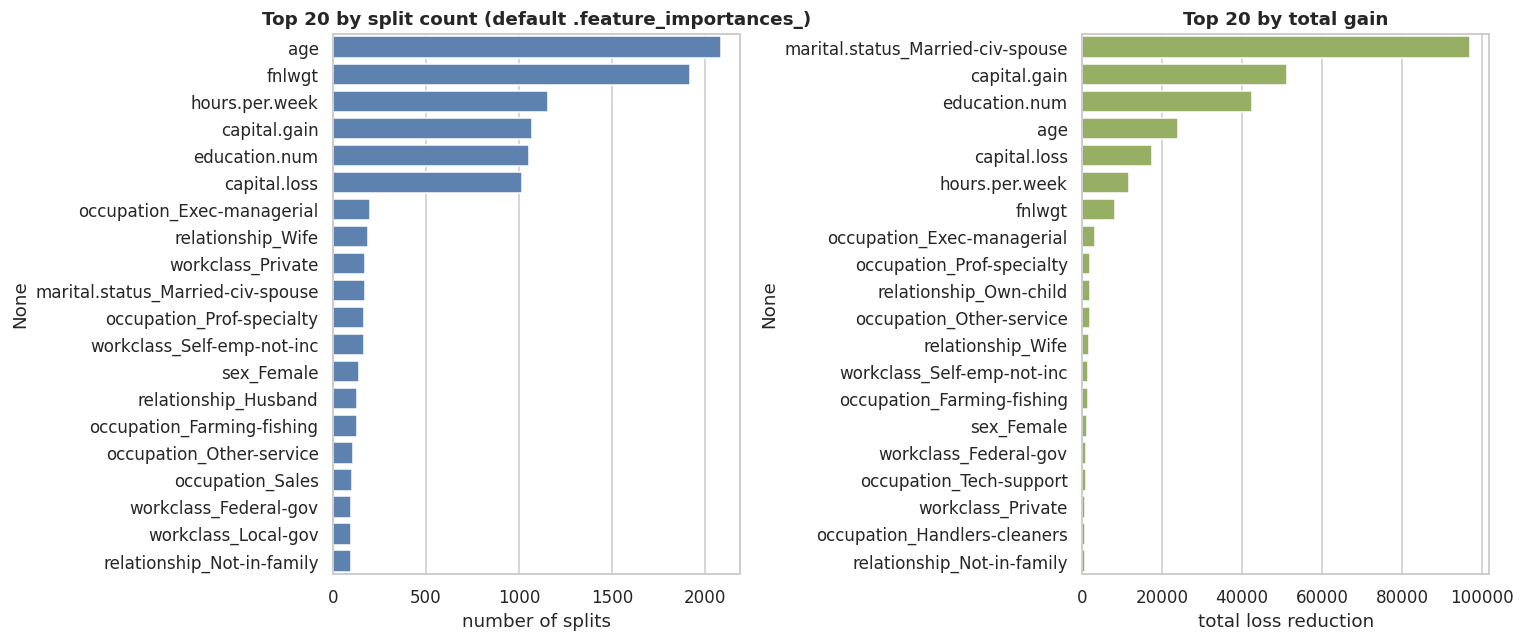

In [68]:
importance_split = pd.Series(best_model.feature_importances_, index=X.columns)
importance_gain = pd.Series(
    best_model.booster_.feature_importance(importance_type="gain"),
    index=X.columns,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_split = importance_split.sort_values(ascending=False).head(20)
sns.barplot(x=top_split.values, y=top_split.index, ax=axes[0], color="#4f81bd")
axes[0].set_title("Top 20 by split count (default .feature_importances_)")
axes[0].set_xlabel("number of splits")

top_gain = importance_gain.sort_values(ascending=False).head(20)
sns.barplot(x=top_gain.values, y=top_gain.index, ax=axes[1], color="#9bbb59")
axes[1].set_title("Top 20 by total gain")
axes[1].set_xlabel("total loss reduction")

plt.tight_layout()
plt.show()

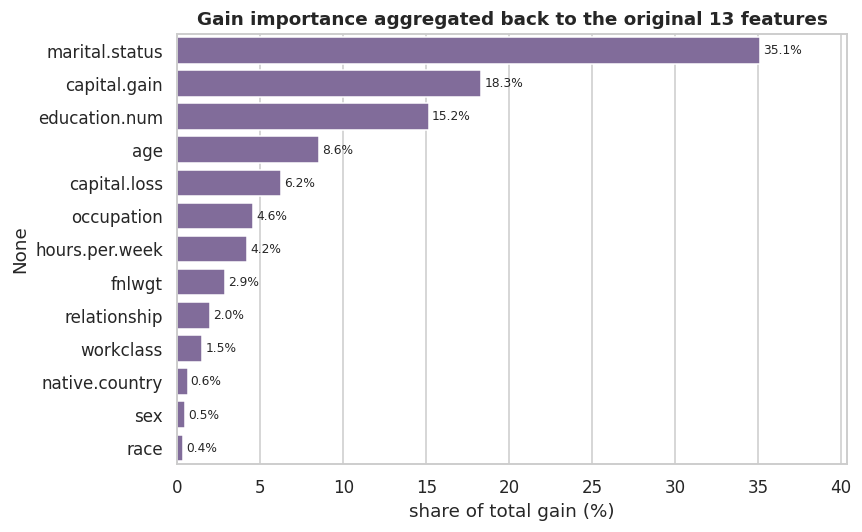

marital.status    35.11
capital.gain      18.32
education.num     15.18
age                8.56
capital.loss       6.22
occupation         4.58
hours.per.week     4.20
fnlwgt             2.89
relationship       1.96
workclass          1.51
native.country     0.62
sex                0.49
race               0.36


In [69]:
# Roll one-hot columns back up to their original feature for a readable ranking
def original_feature(col):
    for c in categorical:
        if col.startswith(c + "_"):
            return c
    return col

grouped_gain = (importance_gain.groupby(importance_gain.index.map(original_feature))
                               .sum()
                               .sort_values(ascending=False))
grouped_pct = 100 * grouped_gain / grouped_gain.sum()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=grouped_pct.values, y=grouped_pct.index, ax=ax, color="#8064a2")
ax.bar_label(ax.containers[0], fmt="%.1f%%", fontsize=8, padding=2)
ax.set_title("Gain importance aggregated back to the original 13 features")
ax.set_xlabel("share of total gain (%)")
ax.set_xlim(0, grouped_pct.max() * 1.15)
plt.tight_layout()
plt.show()

print(grouped_pct.round(2).to_string())

### 5.2 Permutation importance

Split and gain importance are computed from the model's internal structure on
**training** data, so they are biased toward high-cardinality features and can
credit a feature that the model merely used a lot without it generalising.
Permutation importance is model-agnostic and measured on the **held-out test
set**: shuffle one column, see how much the score drops, repeat. It answers a
different and more honest question, namely how much the model's real predictive
performance depends on that feature.

Permutation importance computed in 69.5 s


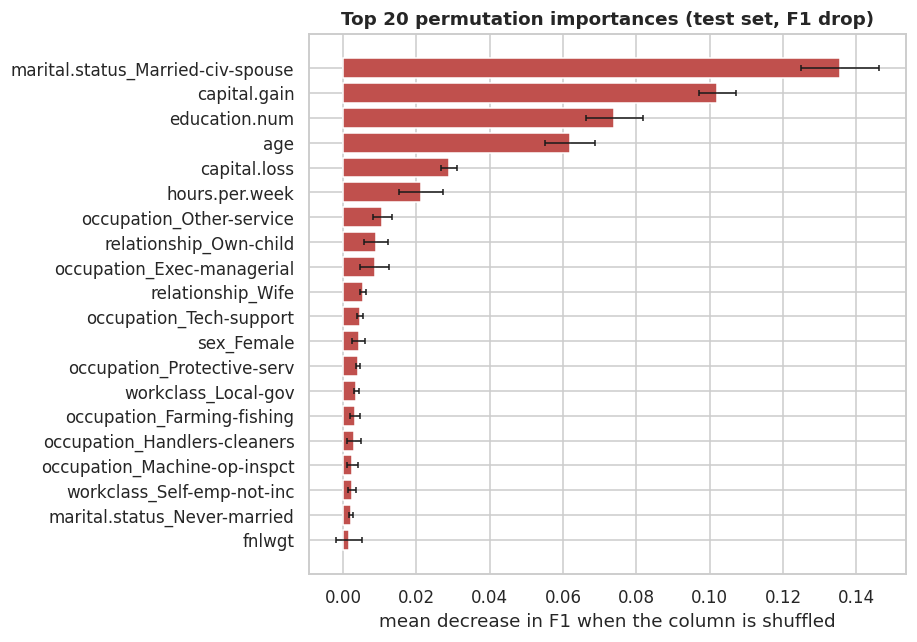

In [70]:
from sklearn.inspection import permutation_importance

t0 = time.perf_counter()
perm = permutation_importance(
    best_model, X_test, y_test,
    scoring="f1",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
print(f"Permutation importance computed in {time.perf_counter() - t0:.1f} s")

perm_mean = pd.Series(perm.importances_mean, index=X.columns)
perm_std = pd.Series(perm.importances_std, index=X.columns)

top_perm = perm_mean.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(top_perm.index[::-1], top_perm.values[::-1],
        xerr=perm_std[top_perm.index][::-1], color="#c0504d",
        error_kw={"lw": 1, "capsize": 2})
ax.set_title("Top 20 permutation importances (test set, F1 drop)")
ax.set_xlabel("mean decrease in F1 when the column is shuffled")
plt.tight_layout()
plt.show()

In [71]:
# Where do the two methods disagree?
compare = pd.DataFrame({
    "gain_rank": importance_gain.rank(ascending=False).astype(int),
    "perm_rank": perm_mean.rank(ascending=False).astype(int),
    "gain": importance_gain.round(0),
    "perm_f1_drop": perm_mean.round(5),
})
compare["rank_shift"] = compare["gain_rank"] - compare["perm_rank"]

print("Features the model SPLITS on a lot but barely NEEDS "
      "(high gain rank, low permutation rank):")
print(compare.sort_values("rank_shift").head(8).to_string())
print()
print("fnlwgt specifically:")
print(compare.loc[["fnlwgt"]].to_string())
print()
print(f"fnlwgt share of total gain: "
      f"{100 * importance_gain['fnlwgt'] / importance_gain.sum():.2f}%")
print(f"fnlwgt permutation F1 drop: {perm_mean['fnlwgt']:+.5f}")

Features the model SPLITS on a lot but barely NEEDS (high gain rank, low permutation rank):
                              gain_rank  perm_rank    gain  perm_f1_drop  rank_shift
occupation_Prof-specialty             9         86  2003.0      -0.00049         -77
occupation_Sales                     22         92   561.0      -0.00160         -70
relationship_Husband                 26         85   494.0      -0.00045         -59
marital.status_Widowed               33         91   313.0      -0.00124         -58
native.country_United-States         31         89   408.0      -0.00069         -58
race_Black                           34         87   288.0      -0.00066         -53
race_Amer-Indian-Eskimo              42         90   131.0      -0.00083         -48
native.country_Missing               41         88   144.0      -0.00068         -47

fnlwgt specifically:
        gain_rank  perm_rank    gain  perm_f1_drop  rank_shift
fnlwgt          7         20  8077.0       0.00161        

### 5.3 Reading the important plots

Aggregating both measures back to the original 13 features and make the comparison
readable:

| feature | share of gain | permutation F1 drop |
|---|---|---|
| marital.status | 35.11% | 0.1367 |
| capital.gain | 18.32% | 0.1021 |
| education.num | 15.18% | 0.0740 |
| age | 8.56% | 0.0618 |
| capital.loss | 6.22% | 0.0289 |
| occupation | 4.58% | 0.0379 |
| hours.per.week | 4.20% | 0.0213 |
| **fnlwgt** | **2.89%** | **0.0016** |
| relationship | 1.96% | 0.0168 |
| workclass | 1.51% | 0.0104 |
| native.country | 0.62% | -0.0006 |
| sex | 0.49% | 0.0041 |
| race | 0.36% | -0.0005 |

# Feature Importance: Where They Agree and Where They Disagree

## Where they look the same

The top four features are the same under both methods and appear in the same order. `marital.status` is the most important feature, followed by `capital.gain`, `education.num`, and `age`. The `marital.status` feature is mostly driven by the `Married-civ-spouse` category and contributes about **0.1356 F1** on its own. In simple terms, being married to a civilian spouse is related to factors such as age, stability, and household income. `capital.gain` is also useful because it gives information about a person's wealth. `education.num` is useful because education is generally related to income, while `age` can capture experience and career progression. The important point is that **both methods agree on these four features**, so there is strong evidence that the model is actually using them.

## Where they disagree, and why it matters

The biggest disagreement is with `fnlwgt`. Gain importance says that `fnlwgt` is fairly important: it ranks **7th out of 92 features** and accounts for **2.89% of the total gain**. However, permutation importance gives it a value of only **0.0016**, which is very small compared with the contribution of `marital.status`. This tells us that the model does not really need `fnlwgt` to make good predictions on unseen data.

The reason is that `fnlwgt` is a census sampling weight. It is a continuous variable with many different possible values, but it does not have a meaningful direct relationship with a person's income. A decision tree can create many different split points for a continuous feature. Some of those splits can look useful simply because of random patterns in the training data. Gain importance sees those improvements during training and treats them as useful. Permutation importance does a different test: it takes unseen data, randomly shuffles `fnlwgt`, and checks whether the model becomes worse. Since the model barely changes, we learn that `fnlwgt` was probably not providing meaningful information.

## It gets worse further down

The disagreement becomes even clearer for some other features. `native.country` has a permutation importance of **-0.0006**, while `race` has **-0.0005**. Individual features such as `occupation_Sales` and `marital.status_Widowed` are even more negative, with values of **-0.0016** and **-0.0012**. A negative permutation importance means that the model actually performs **slightly better** after the feature is randomly shuffled. This does not mean that shuffling the feature magically makes it useful. Instead, it suggests that the feature was probably adding a small amount of noise to the model rather than useful information.

A good example is `occupation_Prof-specialty`. Gain importance ranks it **9th out of 92 features**, which makes it look very important. However, permutation importance ranks it **86th**. This is a large difference. It shows why we should not automatically trust the feature ranking produced by gain importance alone. A feature can look important during training without actually helping the model make predictions on new data.

## The practical lesson

The main lesson is that we should be careful when using `.feature_importances_` from a tree model. Gain or impurity importance is calculated from what happened during training, so it can sometimes give high importance to continuous or high-cardinality features simply because the model had many opportunities to find splits that looked useful. This can make a noisy feature appear more important than it really is.

Permutation importance gives us a more practical test. Instead of asking whether the feature helped the model during training, it asks what happens when we destroy the information in that feature and test the model on data it has not seen before. If the model's performance does not change, the feature probably does not provide much useful information.

For this dataset, `fnlwgt` is therefore a good candidate to remove. Removing it has almost no effect on test F1, while also removing a feature that could make the model's feature-importance explanation misleading. The simple takeaway is: **gain importance tells us what the model used during training, while permutation importance tells us whether the feature actually matters for predictions on unseen data.**


# Task 5 A Write up on which Model would I Actually Ship?

## Recommendation

I would ship **LightGBM**. It gives the best overall results among the models tested, while also being much faster to train. For tuning, I would use a small **Optuna study** or **Randomized Search** instead of Grid Search. However, I would treat tuning mainly as a quick sanity check rather than expecting it to produce a large improvement, because the default LightGBM settings are already performing very well on this dataset.

## On accuracy

The results clearly favor LightGBM across accuracy, F1, and ROC AUC. The single decision tree gets **1.0000 training accuracy**, but only **0.8102 test accuracy**. This is a classic example of overfitting where the tree has learned the training data extremely well but does not perform nearly as well on new data. It is also only slightly better than the majority class baseline of **0.7592**.

Bagging improves the test accuracy to **0.8457** while Random Forest reaches **0.8543**. Both boosted models perform even better than Random Forest. LightGBM gives the best results with **0.8712 accuracy**, **0.7102 F1**, and **0.9242 ROC AUC**. The difference between LightGBM and Random Forest is especially important for F1 where LightGBM is higher by **0.0385**. F1 matters here because the dataset is about **76% negative and 24% positive**. Because of this imbalance a model can achieve reasonably high accuracy simply by predicting the majority class most of the time. F1 gives us a better idea of how well the model is finding the positive class.

## On training time

Training time makes LightGBM even more attractive. LightGBM trains on the full dataset in only **0.28 seconds**. This is roughly **14 times faster** than scikit-learn's `GradientBoostingClassifier` which takes **3.98 seconds** and it is also faster than Random Forest which takes **2.46 seconds**. At the same time LightGBM performs better than both models on the evaluation metrics.

This means that with LightGBM we are not really choosing between speed and accuracy instead we get both. A model that trains in less than a second can be retrained quickly when new data becomes available. It also makes experimentation much easier because we can run more experiments without waiting several minutes for every training process.

## On tuning cost, and an important result

The tuning experiments also show why Grid Search is not a good choice for this particular task. Grid Search performed **270 model fits** and took **248.8 seconds**. Optuna found the **same best configuration** using only **125 fits** and took **108.9 seconds**. Randomized Search came within **0.0020 CV F1** of the best result while using only **75 fits** and taking **90.5 seconds**.

In other words Grid Search used considerably more computing time without giving us a better result. As the number of parameters increases this problem becomes even bigger because Grid Search has to test combinations of the values we manually provide. Adding more parameters can therefore cause the number of combinations to grow very quickly.

There is also an important result from the final test set **tuning did not improve LightGBM**. The tuned LightGBM achieved **0.8704 accuracy** and **0.7076 F1**, while the default LightGBM achieved **0.8712 accuracy** and **0.7102 F1**. The difference is only about **0.003 F1**, which is very small. Therefore it would be misleading to say that tuning made the model worse. A better interpretation is that **tuning did not produce a measurable improvement on this dataset**. The default LightGBM settings were already very close to the best result so the tuning process mainly confirmed that we were already in a good place.

## What I would actually do

I would ship **LightGBM using the default settings** as the starting point. The default model already gives almost all of the performance we were able to achieve without spending additional time on tuning. However, I would still perform a small tuning experiment before finalizing the model, because this confirms whether there is any easy improvement available.

I would use around **20 to 30 Optuna trials** and search over continuous parameter ranges rather than a small list of manually selected values. This is where Optuna can be more useful because it can adapt its search based on the results it has already observed. I would choose Optuna mainly because it scales better, supports pruning, and allows the study to be saved and continued later. I would not claim that Optuna was dramatically better than Randomized Search in this particular experiment, because the difference here was not large enough to justify that conclusion.

Based on the feature-importance analysis from the previous task, I would also remove `fnlwgt`. Its permutation importance showed that it provides almost no useful information on unseen data. I would also investigate `race` and `native.country`, because both have negative permutation importance. These features require additional care because they can introduce fairness concerns, so their predictive contribution should be evaluated carefully rather than assuming that keeping them is automatically beneficial.

## Final takeaway

The overall conclusion is straightforward: **LightGBM gives the best combination of predictive performance and training speed in this experiment**. Its default settings are already strong, and the tuning experiments did not produce a meaningful improvement. Therefore, rather than spending a large amount of computing time searching through many parameter combinations, I would keep the tuning process small, validate the model properly, remove features that do not provide useful information, and focus on choosing the probability threshold based on the real-world cost of prediction errors.


---

## Summary of all results

In [72]:
final = pd.concat([
    task2.assign(stage="Task 2: bagging"),
    pd.DataFrame(boost_results).drop(columns="_fitted").assign(stage="Task 3: boosting"),
    pd.DataFrame([{
        "model": f"LightGBM tuned ({best_row['method']})",
        "train_acc": accuracy_score(y_train, best_model.predict(X_train)),
        "test_acc": accuracy_score(y_test, pred),
        "gap": accuracy_score(y_train, best_model.predict(X_train)) - accuracy_score(y_test, pred),
        "test_f1": f1_score(y_test, pred),
        "test_auc": roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]),
        "fit_time_s": np.nan,
        "stage": "Task 4: tuned",
    }]),
], ignore_index=True)

final = final[["stage", "model", "train_acc", "test_acc", "gap",
               "test_f1", "test_auc", "fit_time_s"]]
for c in ["train_acc", "test_acc", "gap", "test_f1", "test_auc"]:
    final[c] = final[c].round(4)
final["fit_time_s"] = final["fit_time_s"].round(2)
print(final.to_string(index=False))

           stage                         model  train_acc  test_acc    gap  test_f1  test_auc  fit_time_s
 Task 2: bagging Decision Tree (unconstrained)     1.0000    0.8102 0.1898   0.6071    0.7415        0.87
 Task 2: bagging            Bagging (10 trees)     0.9877    0.8457 0.1420   0.6407    0.8804        8.01
 Task 2: bagging     Random Forest (100 trees)     1.0000    0.8543 0.1457   0.6717    0.9011       12.26
Task 3: boosting   Gradient Boosting (sklearn)     0.8709    0.8614 0.0095   0.6762    0.9152       18.24
Task 3: boosting                      LightGBM     0.8903    0.8712 0.0191   0.7102    0.9242        1.10
   Task 4: tuned LightGBM tuned (GridSearchCV)     0.8924    0.8704 0.0219   0.7076    0.9251         NaN


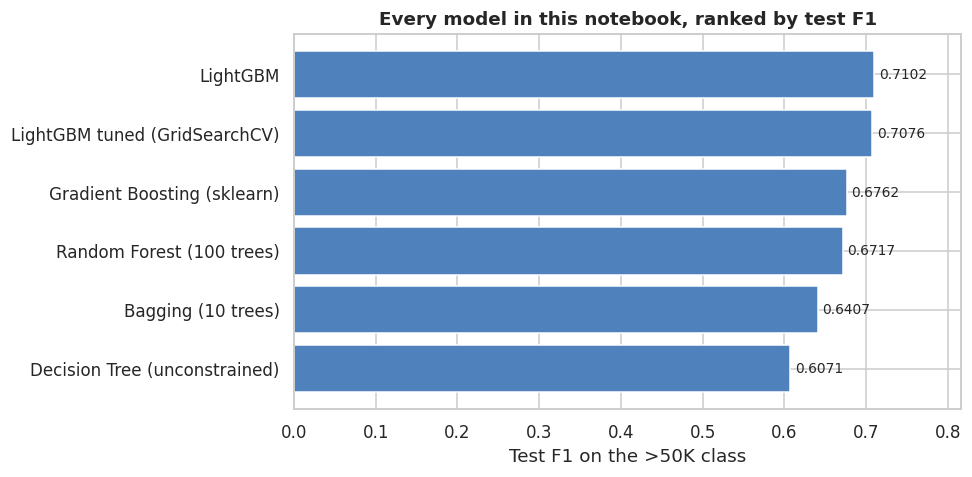

In [74]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_final = final.dropna(subset=["test_f1"]).sort_values("test_f1")
ax.barh(plot_final["model"], plot_final["test_f1"], color="#4f81bd")
ax.bar_label(ax.containers[0], fmt="%.4f", fontsize=9, padding=3)
ax.set_xlim(0, plot_final["test_f1"].max() * 1.15)
ax.set_xlabel("Test F1 on the >50K class")
ax.set_title("Every model in this notebook, ranked by test F1")
plt.tight_layout()
plt.show()